In [2]:
import os
os.getcwd()

'c:\\Users\\ugne.keliauskaite\\Bruegel GitLab\\research-2021-11-european-natural-gas-imports\\standalone pieces of code'

In [3]:
# Share_point = r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2021-11 European natural gas imports\Code\Imports'
Share_point = r'C:\Users\ugne.keliauskaite\Bruegel\Research - 2021-11 European natural gas imports\Code\Imports'

In [4]:
os.chdir(Share_point)

In [5]:
import json
import requests
import pandas as pd
import numpy as np

from datetime import datetime
from datetime import date, timedelta
from dateutil.relativedelta import relativedelta

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.dates import DateFormatter
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns

import eurostat  # python wrapper for taking data.
import time

In [6]:
# Converter for metric tonnes to M3m 
# converter = -0.001397
converter = -0.00138

In [77]:
d4

,Port_Country,2023-12-31 00:00:00,2023-11-30 00:00:00,2023-10-31 00:00:00,2023-09-30 00:00:00,2023-08-31 00:00:00,2023-07-31 00:00:00,2023-06-30 00:00:00,2023-05-31 00:00:00,2023-04-30 00:00:00,2023-03-31 00:00:00,2023-02-28 00:00:00,2023-01-31 00:00:00
Origin_Berthcountry,,,,,,,,,,,,,
Indonesia,Croatia,NaN,NaN,NaN,NaN,NaN,NaN,-63084.6,NaN,NaN,NaN,NaN,NaN
Mozambique,Croatia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-70968.15,NaN,NaN,-70887.15
Nigeria,Croatia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-72071.10,NaN,NaN,NaN
Oman,Croatia,NaN,NaN,NaN,NaN,-72679.95,NaN,-69663.6,-71256.15,NaN,NaN,NaN,NaN
Trinidad & Tobago,Croatia,-71853.30,NaN,-69844.5,-71840.70,NaN,-70553.25,NaN,-35702.10,NaN,NaN,-70330.95,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Peru,United Kingdom,-141527.70,-281677.95,-209646.9,NaN,NaN,NaN,NaN,-126904.50,-206637.30,-70672.05,-141374.25,-138664.80
Qatar,United Kingdom,NaN,NaN,-306800.1,NaN,-219234.60,-143137.35,-198321.3,-304279.65,-414097.20,-153006.75,-109405.80,-251602.65
Spain,United Kingdom,NaN,-33286.95,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### In Million tonnes

In [7]:
d1 = pd.read_excel('raw_data/LNG/Europe LNG 2017_2018.xlsx',index_col=1)
d2 = pd.read_excel('raw_data/LNG/Europe LNG 2019_2020.xlsx',index_col=1)
d3 = pd.read_excel('raw_data/LNG/Europe LNG 2021_2022.xlsx',index_col=1)
d4 = pd.read_excel('raw_data/LNG/Europe LNG 2023.xlsx',index_col=1)
d5 = pd.read_excel('raw_data/LNG/Europe LNG 2024.xlsx',index_col=1)
d6 = pd.read_excel('raw_data/LNG/Europe LNG 2025.xlsx',index_col=1)


d6 = d6.groupby(['Port_Country', 'Origin_Berthcountry']).sum().reset_index()


C:\Users\ugne.keliauskaite\AppData\Local\Temp\ipykernel_35124\2316559946.py:9: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  d6 = d6.groupby(['Port_Country', 'Origin_Berthcountry']).sum().reset_index()


In [8]:
# Merge 2017 to 2020
df_20 = pd.merge(d1,d2,on=['Origin_Berthcountry','Port_Country'],how='outer')

In [9]:
# Merge 2017 to 2022
df_22 = pd.merge(df_20,d3,on=['Origin_Berthcountry','Port_Country'],how='outer')

In [10]:
#df_22
#d4

In [11]:
# Merge 2022 to 2023
df_23 = pd.merge(df_22,d4,on=['Origin_Berthcountry','Port_Country'],how='outer')

In [12]:
# Merge 2023 to 2024
df_24 = pd.merge(df_23,d5,on=['Origin_Berthcountry','Port_Country'],how='outer')

In [13]:
# Merge 2024 to 2025
df_25 = pd.merge(df_24,d6,on=['Origin_Berthcountry','Port_Country'],how='outer')

In [14]:
not_EU = ['United Kingdom','Turkey','Russia']
df_EU27 = df_25.loc[~df_25['Port_Country'].isin((not_EU))] 

In [15]:
# you can void running it
df_EU27

,Origin_Berthcountry,Port_Country,2018-12-31 00:00:00,2018-11-30 00:00:00,2018-10-31 00:00:00,2018-09-30 00:00:00,2018-08-31 00:00:00,2018-07-31 00:00:00,2018-06-30 00:00:00,2018-05-31 00:00:00,...,2024-06-30 00:00:00,2024-05-31 00:00:00,2024-04-30 00:00:00,2024-03-31 00:00:00,2024-02-29 00:00:00,2024-01-31 00:00:00,2025-04-30 00:00:00,2025-03-31 00:00:00,2025-02-28 00:00:00,2025-01-31 00:00:00
0,Netherlands,Lithuania,-1571.85,NaN,-1043.55,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Nigeria,Lithuania,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Norway,Lithuania,-59432.40,-61424.1,NaN,-123175.35,NaN,-61358.85,-61424.1,-118815.75,...,-61489.80,NaN,-63980.10,-119702.25,-59180.85,-120107.25,0.00,-66689.10,-133719.3,-61228.35
3,Trinidad & Tobago,Lithuania,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,United States of America,Lithuania,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-64884.15,NaN,-34807.05,-71650.80,-107400.60,NaN,-74290.95,-143652.60,0.0,-213099.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,Germany,Sweden,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
233,Norway,Bunkering,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,-3201.75,0.00,0.0,0.00
234,Australia,France,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.00,-70700.85,0.0,0.00
235,Equatorial Guinea,Germany,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.00,-72071.10,0.0,0.00


In [16]:
## Here we get 
dff = df_EU27.groupby(['Origin_Berthcountry']).sum(numeric_only=True)
dff


,2018-12-31,2018-11-30,2018-10-31,2018-09-30,2018-08-31,2018-07-31,2018-06-30,2018-05-31,2018-04-30,2018-03-31,...,2024-06-30,2024-05-31,2024-04-30,2024-03-31,2024-02-29,2024-01-31,2025-04-30,2025-03-31,2025-02-28,2025-01-31
Origin_Berthcountry,,,,,,,,,,,,,,,,,,,,,
Algeria,-615891.60,-559200.15,-407020.05,-405702.90,-291444.30,-393055.65,-619292.25,-416672.55,-389765.25,-341546.40,...,-677976.30,-558836.10,-890781.30,-550746.45,-545318.55,-438710.85,-192906.45,-529283.25,-292205.25,-228833.55
Angola,0.00,-137366.55,-133161.30,0.00,0.00,0.00,0.00,0.00,-133146.45,0.00,...,0.00,0.00,-66014.10,-66738.60,-66738.60,-66210.30,0.00,-332398.35,-404323.65,-132978.60
Argentina,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Australia,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-70700.85,0.00,0.00
Belgium,0.00,-7517.25,-7533.00,-7525.35,-67580.10,-69716.25,-7533.00,-7525.35,-6582.60,-9739.80,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Brazil,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Cameroon,-56063.25,-61735.50,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-71333.10,-62027.55
China,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
"Congo, Republic",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,-64185.30,0.00,-62408.25,0.00,0.00,0.00,-58047.75,0.00,-58047.75,-57985.65


In [17]:
dff_T = dff.T #drop(['nan_x','nan_y'])
dff_T

Origin_Berthcountry,Algeria,Angola,Argentina,Australia,Belgium,Brazil,Cameroon,China,"Congo, Republic",Dominican Republic,...,Qatar,Russia,Singapore,South Korea,Spain,Trinidad & Tobago,United Arab Emirates,United Kingdom,United States of America,Virgin Islands (U.S.A.)
2018-12-31,-615891.60,0.00,0.0,0.00,0.00,0.0,-56063.25,0.0,0.00,0.0,...,-747656.10,-487366.20,0.0,0.0,0.00,-224977.95,0.0,0.0,-555924.60,0.0
2018-11-30,-559200.15,-137366.55,0.0,0.00,-7517.25,0.0,-61735.50,0.0,0.00,0.0,...,-920236.05,-563819.85,0.0,0.0,0.00,-112722.75,0.0,0.0,-380014.20,0.0
2018-10-31,-407020.05,-133161.30,0.0,0.00,-7533.00,0.0,0.00,0.0,0.00,0.0,...,-1045076.40,-564659.10,0.0,0.0,0.00,-114088.50,0.0,0.0,-291582.00,0.0
2018-09-30,-405702.90,0.00,0.0,0.00,-7525.35,0.0,0.00,0.0,0.00,0.0,...,-938289.15,-277384.95,0.0,0.0,0.00,-113405.85,0.0,0.0,-125147.25,0.0
2018-08-31,-291444.30,0.00,0.0,0.00,-67580.10,0.0,0.00,0.0,0.00,0.0,...,-1322908.65,-143581.05,0.0,0.0,0.00,-170850.60,0.0,0.0,-134967.60,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-01-31,-438710.85,-66210.30,0.0,0.00,0.00,0.0,0.00,0.0,0.00,0.0,...,-687998.70,-1492260.75,0.0,0.0,-21721.50,-141858.90,0.0,0.0,-4041374.40,0.0
2025-04-30,-192906.45,0.00,0.0,0.00,0.00,0.0,0.00,0.0,-58047.75,0.0,...,-199509.30,-501265.35,0.0,0.0,-2759.85,-72017.55,0.0,0.0,-1938434.85,0.0
2025-03-31,-529283.25,-332398.35,0.0,-70700.85,0.00,0.0,0.00,0.0,0.00,0.0,...,-1025299.80,-1289835.45,0.0,0.0,-15168.60,-71039.70,0.0,0.0,-5312496.15,-73631.7
2025-02-28,-292205.25,-404323.65,0.0,0.00,0.00,0.0,-71333.10,0.0,-58047.75,0.0,...,-888179.85,-1349417.25,0.0,0.0,-88922.70,-71763.30,0.0,0.0,-3826282.95,0.0


In [18]:
dff_T.index = pd.to_datetime(dff_T.index)
dff_T = dff_T.sort_index()
dff_T

Origin_Berthcountry,Algeria,Angola,Argentina,Australia,Belgium,Brazil,Cameroon,China,"Congo, Republic",Dominican Republic,...,Qatar,Russia,Singapore,South Korea,Spain,Trinidad & Tobago,United Arab Emirates,United Kingdom,United States of America,Virgin Islands (U.S.A.)
2017-01-31,-294706.35,-66951.90,0.0,0.00,-9736.65,0.0,0.00,0.0,0.00,0.0,...,-785239.65,0.00,0.0,0.0,0.00,-57186.90,0.0,-31113.45,-73359.00,0.0
2017-02-28,-572303.70,-132934.05,0.0,0.00,-9739.80,0.0,0.00,0.0,0.00,0.0,...,-868583.70,0.00,0.0,0.0,0.00,-66744.90,0.0,0.00,-234094.05,0.0
2017-03-31,-736423.65,0.00,0.0,0.00,-6568.65,0.0,0.00,0.0,0.00,0.0,...,-838356.30,0.00,0.0,0.0,0.00,0.00,0.0,0.00,0.00,0.0
2017-04-30,-350212.50,0.00,0.0,0.00,-12897.45,0.0,0.00,0.0,0.00,0.0,...,-1103457.15,0.00,0.0,0.0,0.00,-117922.50,0.0,0.00,0.00,0.0
2017-05-31,-596601.00,-65872.35,0.0,0.00,0.00,0.0,0.00,0.0,0.00,0.0,...,-1257913.35,0.00,0.0,0.0,0.00,0.00,0.0,0.00,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,-426583.80,-133232.85,0.0,0.00,-3195.00,0.0,0.00,0.0,0.00,0.0,...,-1017115.65,-1565259.75,0.0,0.0,-16495.20,-71787.60,0.0,0.00,-2994975.90,0.0
2025-01-31,-228833.55,-132978.60,0.0,0.00,0.00,0.0,-62027.55,0.0,-57985.65,0.0,...,-678697.20,-1488501.00,0.0,0.0,-17811.90,-71651.70,0.0,0.00,-4739247.00,0.0
2025-02-28,-292205.25,-404323.65,0.0,0.00,0.00,0.0,-71333.10,0.0,-58047.75,0.0,...,-888179.85,-1349417.25,0.0,0.0,-88922.70,-71763.30,0.0,0.00,-3826282.95,0.0
2025-03-31,-529283.25,-332398.35,0.0,-70700.85,0.00,0.0,0.00,0.0,0.00,0.0,...,-1025299.80,-1289835.45,0.0,0.0,-15168.60,-71039.70,0.0,0.00,-5312496.15,-73631.7


In [19]:
# check EU LNG imports in 2022
# dff_T['2022'].sum().sum()/1000000

### in M3m

In [20]:
dff_M3m = dff_T * converter

In [21]:
# Remove European re-exports
del dff_M3m['Belgium']
del dff_M3m['France']
del dff_M3m['Lithuania']
del dff_M3m['Netherlands']
del dff_M3m['Spain']
del dff_M3m['Germany']
del dff_M3m['Finland']

In [22]:
dff_EU = dff_M3m


In [23]:
dff_M3m.columns

Index(['Algeria', 'Angola', 'Argentina', 'Australia', 'Brazil', 'Cameroon',
       'China', 'Congo, Republic', 'Dominican Republic', 'Egypt',
       'Equatorial Guinea', 'Indonesia', 'Jamaica', 'Malaysia', 'Mexico',
       'Mozambique', 'Nigeria', 'Norway', 'Oman', 'Peru', 'Qatar', 'Russia',
       'Singapore', 'South Korea', 'Trinidad & Tobago', 'United Arab Emirates',
       'United Kingdom', 'United States of America',
       'Virgin Islands (U.S.A.)'],
      dtype='object', name='Origin_Berthcountry')

In [24]:
dff_M3m.tail()

Origin_Berthcountry,Algeria,Angola,Argentina,Australia,Brazil,Cameroon,China,"Congo, Republic",Dominican Republic,Egypt,...,Peru,Qatar,Russia,Singapore,South Korea,Trinidad & Tobago,United Arab Emirates,United Kingdom,United States of America,Virgin Islands (U.S.A.)
2024-12-31,588.685644,183.861333,-0.0,-0.000000,-0.0,-0.000000,-0.0,-0.000000,-0.0,-0.0,...,193.078215,1403.619597,2160.058455,-0.0,-0.0,99.066888,-0.0,-0.0,4133.066742,-0.000000
2025-01-31,315.790299,183.510468,-0.0,-0.000000,-0.0,85.598019,-0.0,80.020197,-0.0,-0.0,...,97.973928,936.602136,2054.131380,-0.0,-0.0,98.879346,-0.0,-0.0,6540.160860,-0.000000
2025-02-28,403.243245,557.966637,-0.0,-0.000000,-0.0,98.439678,-0.0,80.105895,-0.0,-0.0,...,-0.000000,1225.688193,1862.195805,-0.0,-0.0,99.033354,-0.0,-0.0,5280.270471,-0.000000
2025-03-31,730.410885,458.709723,-0.0,97.567173,-0.0,-0.000000,-0.0,-0.000000,-0.0,-0.0,...,-0.000000,1414.913724,1779.972921,-0.0,-0.0,98.034786,-0.0,-0.0,7331.244687,101.611746
2025-04-30,266.210901,-0.000000,-0.0,-0.000000,-0.0,-0.000000,-0.0,80.105895,-0.0,-0.0,...,97.894440,275.322834,691.746183,-0.0,-0.0,99.384219,-0.0,-0.0,2675.040093,-0.000000


In [25]:
# look only at the big exporters to the EU
include = ['Algeria','Norway','Nigeria','Qatar','Russia','Trinidad & Tobago','United States of America','Egypt']
exclude = list(set(dff_M3m.columns)-set(include))

In [26]:
## Define an "Other" category
dff_M3m['Other']= dff_M3m[exclude].sum(axis=1)

In [27]:
# dff_M3m['Argentina'].loc['2020':]+dff_M3m['Brazil'].loc['2020':]+dff_M3m['Peru'].loc['2020':]

In [28]:
# os.chdir(r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2021-11 European natural gas imports\Data\LNG') # Gio
os.chdir(r'C:\Users\ugne.keliauskaite\Bruegel\Research - 2021-11 European natural gas imports\Data\LNG') # Ugne

In [29]:
dff_M3m['month'] = dff_M3m.index.strftime("%m")


In [30]:
os.getcwd()

'C:\\Users\\ugne.keliauskaite\\Bruegel\\Research - 2021-11 European natural gas imports\\Data\\LNG'

In [31]:
dff_M3m

Origin_Berthcountry,Algeria,Angola,Argentina,Australia,Brazil,Cameroon,China,"Congo, Republic",Dominican Republic,Egypt,...,Russia,Singapore,South Korea,Trinidad & Tobago,United Arab Emirates,United Kingdom,United States of America,Virgin Islands (U.S.A.),Other,month
2017-01-31,406.694763,92.393622,-0.0,-0.000000,-0.0,-0.000000,-0.0,-0.000000,-0.0,-0.000000,...,-0.000000,-0.0,-0.0,78.917922,-0.0,42.936561,101.235420,-0.000000,462.154410,01
2017-02-28,789.779106,183.448989,-0.0,-0.000000,-0.0,-0.000000,-0.0,-0.000000,-0.0,-0.000000,...,-0.000000,-0.0,-0.0,92.107962,-0.0,-0.000000,323.049789,-0.000000,521.420166,02
2017-03-31,1016.264637,-0.000000,-0.0,-0.000000,-0.0,-0.000000,-0.0,-0.000000,-0.0,-0.000000,...,-0.000000,-0.0,-0.0,-0.000000,-0.0,-0.000000,-0.000000,-0.000000,262.522161,03
2017-04-30,483.293250,-0.000000,-0.0,-0.000000,-0.0,-0.000000,-0.0,-0.000000,-0.0,-0.000000,...,-0.000000,-0.0,-0.0,162.733050,-0.0,-0.000000,-0.000000,-0.000000,244.581471,04
2017-05-31,823.309380,90.903843,-0.0,-0.000000,-0.0,-0.000000,-0.0,-0.000000,-0.0,137.742768,...,-0.000000,-0.0,-0.0,-0.000000,-0.0,-0.000000,-0.000000,-0.000000,429.733863,05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,588.685644,183.861333,-0.0,-0.000000,-0.0,-0.000000,-0.0,-0.000000,-0.0,-0.000000,...,2160.058455,-0.0,-0.0,99.066888,-0.0,-0.000000,4133.066742,-0.000000,575.573850,12
2025-01-31,315.790299,183.510468,-0.0,-0.000000,-0.0,85.598019,-0.0,80.020197,-0.0,-0.000000,...,2054.131380,-0.0,-0.0,98.879346,-0.0,-0.000000,6540.160860,-0.000000,546.304878,01
2025-02-28,403.243245,557.966637,-0.0,-0.000000,-0.0,98.439678,-0.0,80.105895,-0.0,-0.000000,...,1862.195805,-0.0,-0.0,99.033354,-0.0,-0.000000,5280.270471,-0.000000,938.369502,02
2025-03-31,730.410885,458.709723,-0.0,97.567173,-0.0,-0.000000,-0.0,-0.000000,-0.0,-0.000000,...,1779.972921,-0.0,-0.0,98.034786,-0.0,-0.000000,7331.244687,101.611746,859.562118,03


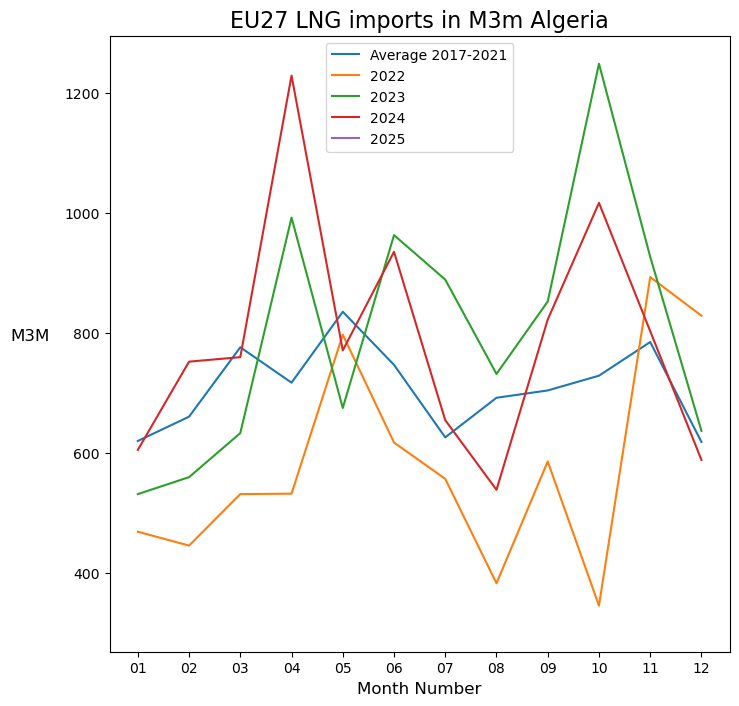

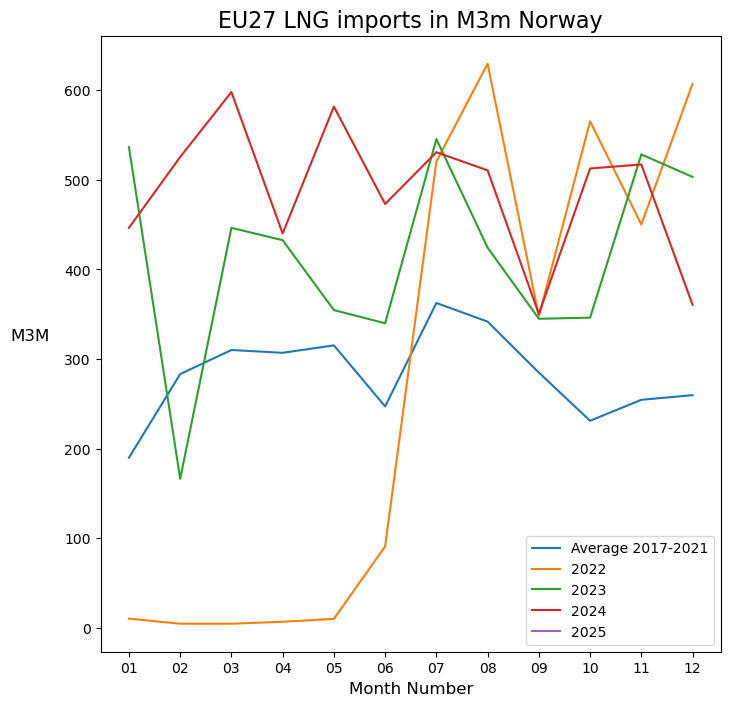

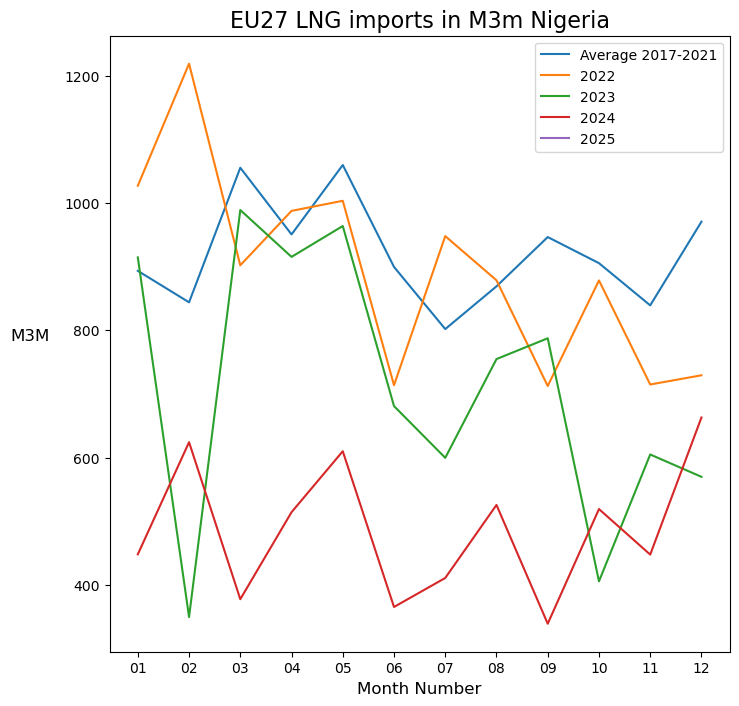

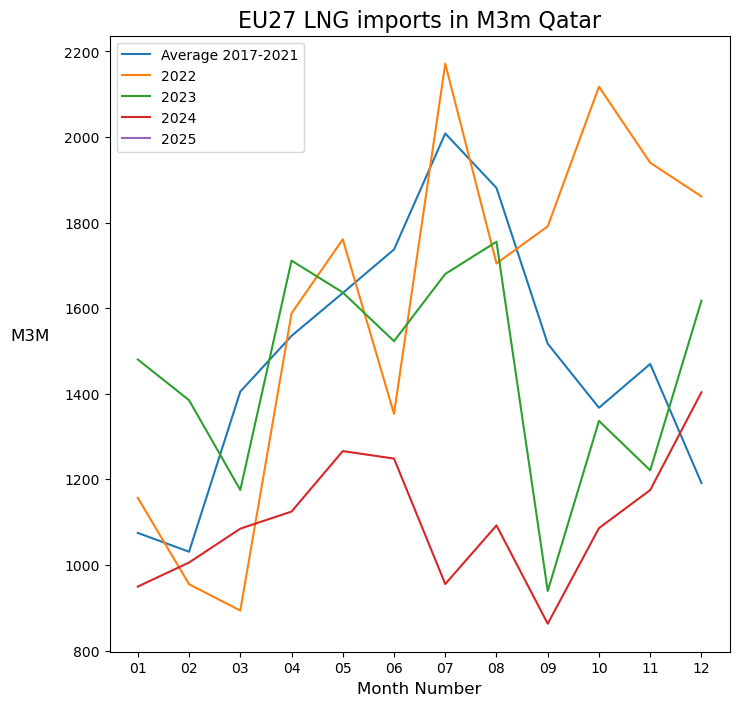

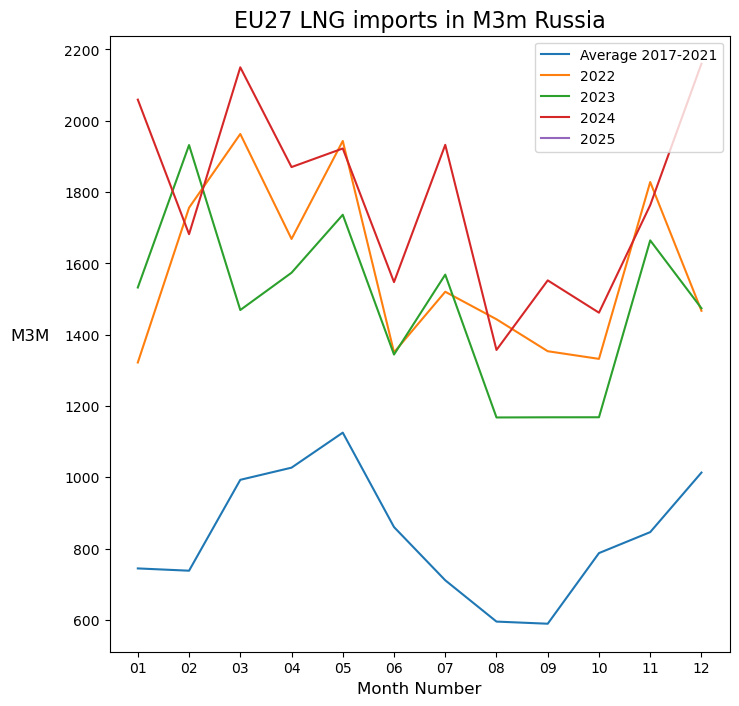

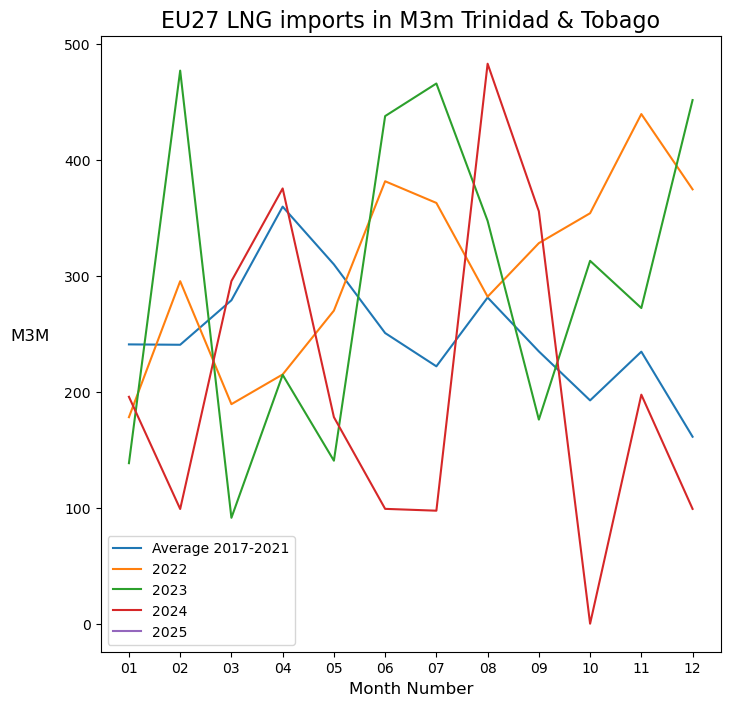

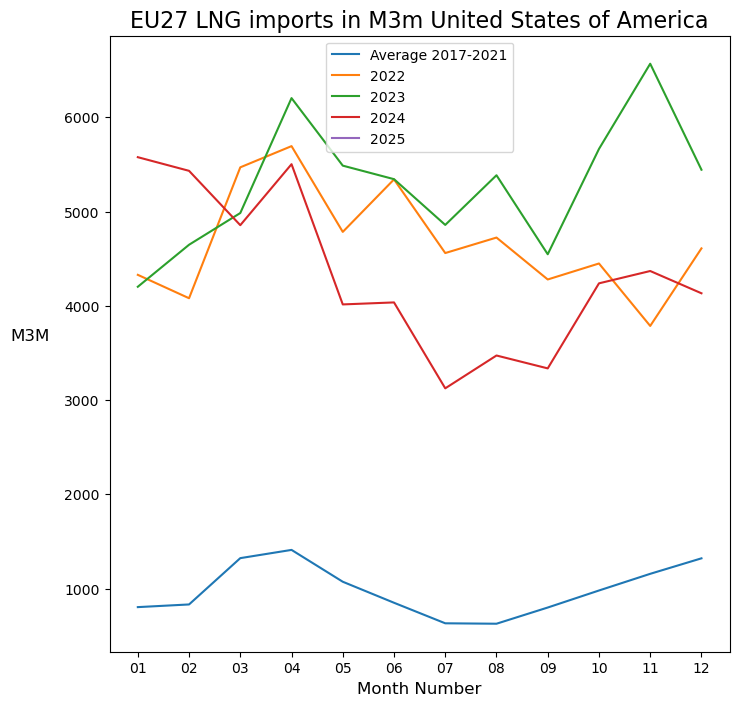

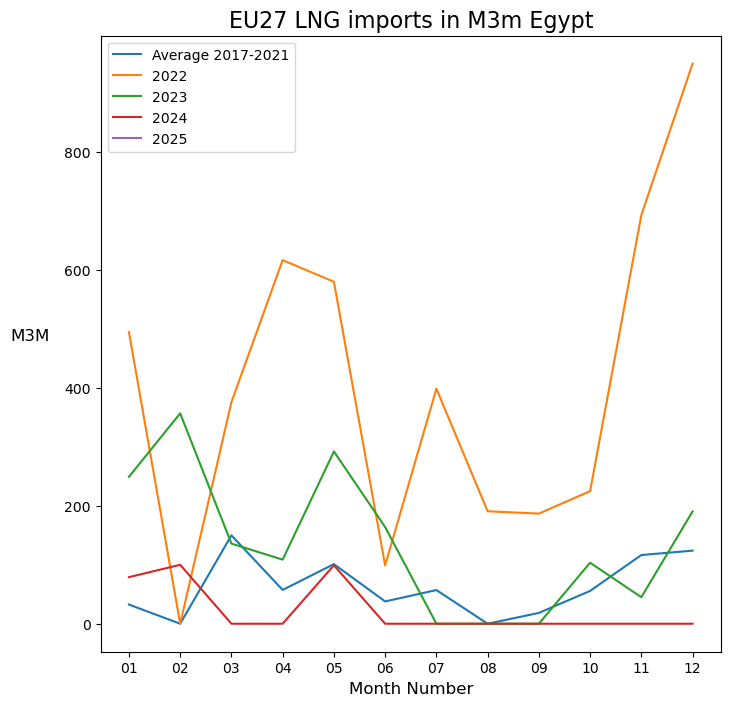

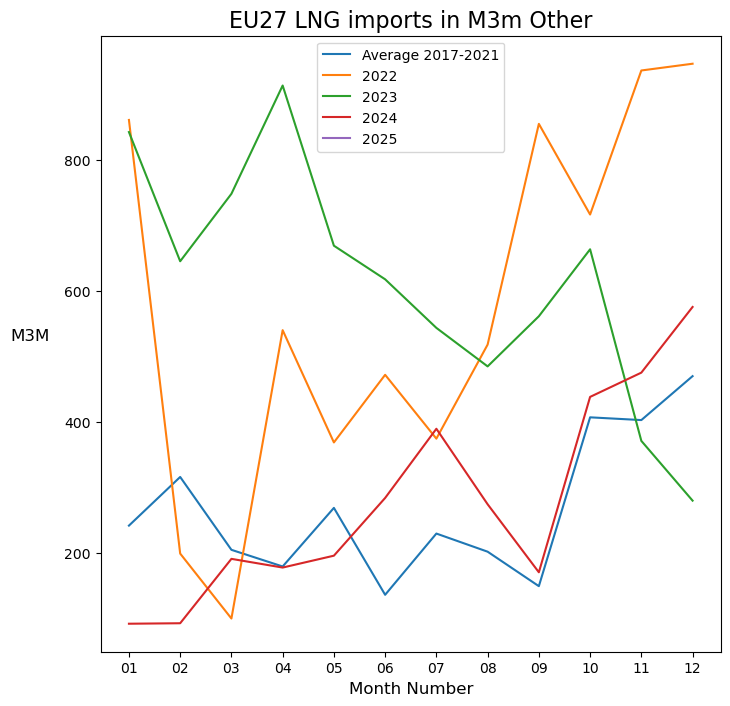

In [32]:
### From country of origin
data = pd.DataFrame()
for country in ['Algeria','Norway','Nigeria','Qatar','Russia','Trinidad & Tobago','United States of America','Egypt','Other']:

    ctemp = dff_M3m[country][:'2025-01-31'] # to update to the last month available
    ctemp=ctemp.to_frame()
    ctemp['month'] = ctemp.index.strftime("%m")
    
#     minvalues = ctemp.loc['2017':'2020'].groupby('month').min()
#     maxvalues = ctemp.loc['2017':'2020'].groupby('month').max()
    avgvalues = ctemp.loc['2017':'2021'].groupby('month').mean()   
#     values2021 = ctemp.loc['2021'].groupby('month').mean()   
    values2022 = ctemp.loc['2022'].groupby('month').max()
    values2023 = ctemp.loc['2023'].groupby('month').max()
    values2024 = ctemp.loc['2024'].groupby('month').max()
    values2025 = ctemp.loc['2025'].groupby('month').max()

    fig, ax = plt.subplots(figsize=(8, 8))

    ax.plot(avgvalues,label='Average 2017-2021')
#     ax.plot(values2021,label='2021')
    ax.plot(values2022,label='2022')
    ax.plot(values2023,label='2023')
    ax.plot(values2024,label='2024')
    ax.plot(values2025,label='2025')


    plt.title('EU27 LNG imports in M3m {}'.format(country),fontsize='16')
    plt.ylabel('M3M',fontsize=12,rotation=0,labelpad=25)
    plt.xlabel('Month Number',fontsize=12,rotation=0)
    plt.legend()
    plt.show()
    fig.savefig('pictures/{}.png'.format(country),dpi=300,bbox_inches="tight")

#     data['{}_min'.format(country)] = minvalues
#     data['{}_max'.format(country)] = maxvalues
    data['{}_avg'.format(country)] = avgvalues
#     data['{}_2021'.format(country)] = values2021 
    data['{}_2022'.format(country)] = values2022
    data['{}_2023'.format(country)] = values2023
    data['{}_2024'.format(country)] = values2024
    data['{}_2025'.format(country)] = values2025

In [33]:
today = date.today()    
data = data.round(1)
data.to_csv('LNG_imports_avg_{}.csv'.format(today))


#### Get only 2019 onwards values

In [34]:
df_late =dff_M3m.loc['2019':]

In [35]:
df_late=df_late.rename(columns={'United States of America':'United States'})

In [36]:
df_late=df_late.drop('month',axis=1)
df_late = df_late[['Qatar','Algeria','Nigeria','Russia','Norway','United States','Trinidad & Tobago','Egypt','Other']]

In [37]:
import os
os.getcwd()

'C:\\Users\\ugne.keliauskaite\\Bruegel\\Research - 2021-11 European natural gas imports\\Data\\LNG'

In [38]:
df_late.to_excel(r'Bloomberg/granular LNG imports.xlsx')

#### Aggregate to avoid problems with Bloomberg

In [39]:
dff_EU = dff_EU.loc['2019':]

In [40]:
dff_EU.columns


Index(['Algeria', 'Angola', 'Argentina', 'Australia', 'Brazil', 'Cameroon',
       'China', 'Congo, Republic', 'Dominican Republic', 'Egypt',
       'Equatorial Guinea', 'Indonesia', 'Jamaica', 'Malaysia', 'Mexico',
       'Mozambique', 'Nigeria', 'Norway', 'Oman', 'Peru', 'Qatar', 'Russia',
       'Singapore', 'South Korea', 'Trinidad & Tobago', 'United Arab Emirates',
       'United Kingdom', 'United States of America', 'Virgin Islands (U.S.A.)',
       'Other', 'month'],
      dtype='object', name='Origin_Berthcountry')

In [41]:
# dff_EU was defined before playing around with include/exlude in dff_M3m (feel free to change)

In [42]:
exclude_2 = ['Argentina','Australia','Brazil','China','Indonesia','Jamaica','Malaysia','Peru','United Kingdom','Singapore','South Korea']

In [43]:
set(dff_EU.columns)-set(exclude_2)

{'Algeria',
 'Angola',
 'Cameroon',
 'Congo, Republic',
 'Dominican Republic',
 'Egypt',
 'Equatorial Guinea',
 'Mexico',
 'Mozambique',
 'Nigeria',
 'Norway',
 'Oman',
 'Other',
 'Qatar',
 'Russia',
 'Trinidad & Tobago',
 'United Arab Emirates',
 'United States of America',
 'Virgin Islands (U.S.A.)',
 'month'}

In [44]:
dff_EU.columns

Index(['Algeria', 'Angola', 'Argentina', 'Australia', 'Brazil', 'Cameroon',
       'China', 'Congo, Republic', 'Dominican Republic', 'Egypt',
       'Equatorial Guinea', 'Indonesia', 'Jamaica', 'Malaysia', 'Mexico',
       'Mozambique', 'Nigeria', 'Norway', 'Oman', 'Peru', 'Qatar', 'Russia',
       'Singapore', 'South Korea', 'Trinidad & Tobago', 'United Arab Emirates',
       'United Kingdom', 'United States of America', 'Virgin Islands (U.S.A.)',
       'Other', 'month'],
      dtype='object', name='Origin_Berthcountry')

In [45]:
dff_EU['Other']=dff_EU[exclude_2].sum(axis=1)

C:\Users\ugne.keliauskaite\AppData\Local\Temp\ipykernel_35124\1128151473.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff_EU['Other']=dff_EU[exclude_2].sum(axis=1)


In [46]:
dff_EU

Origin_Berthcountry,Algeria,Angola,Argentina,Australia,Brazil,Cameroon,China,"Congo, Republic",Dominican Republic,Egypt,...,Russia,Singapore,South Korea,Trinidad & Tobago,United Arab Emirates,United Kingdom,United States of America,Virgin Islands (U.S.A.),Other,month
2019-01-31,617.839731,-0.000000,-0.0,-0.000000,-0.0,-0.000000,-0.0,-0.000000,-0.0,-0.000000,...,1145.546901,-0.0,-0.0,438.547716,-0.0,-0.0,828.032085,-0.000000,159.209496,01
2019-02-28,661.525839,282.933189,-0.0,-0.000000,-0.0,-0.000000,-0.0,-0.000000,-0.0,-0.000000,...,1138.201713,-0.0,-0.0,432.272511,-0.0,-0.0,589.582989,-0.000000,253.302795,02
2019-03-31,749.359458,92.001150,-0.0,-0.000000,-0.0,85.598019,-0.0,-0.000000,-0.0,203.313537,...,1688.294070,-0.0,-0.0,555.785685,-0.0,-0.0,1326.082779,-0.000000,77.790186,03
2019-04-30,1056.090609,91.749024,-0.0,-0.000000,-0.0,-0.000000,-0.0,-0.000000,-0.0,203.330925,...,1867.832001,-0.0,-0.0,699.419259,-0.0,-0.0,1274.430483,-0.000000,0.000000,04
2019-05-31,891.397683,92.001150,-0.0,-0.000000,-0.0,-0.000000,-0.0,-0.000000,-0.0,188.580933,...,1945.275048,-0.0,-0.0,432.147690,-0.0,-0.0,835.040070,-0.000000,0.000000,05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,588.685644,183.861333,-0.0,-0.000000,-0.0,-0.000000,-0.0,-0.000000,-0.0,-0.000000,...,2160.058455,-0.0,-0.0,99.066888,-0.0,-0.0,4133.066742,-0.000000,193.078215,12
2025-01-31,315.790299,183.510468,-0.0,-0.000000,-0.0,85.598019,-0.0,80.020197,-0.0,-0.000000,...,2054.131380,-0.0,-0.0,98.879346,-0.0,-0.0,6540.160860,-0.000000,97.973928,01
2025-02-28,403.243245,557.966637,-0.0,-0.000000,-0.0,98.439678,-0.0,80.105895,-0.0,-0.000000,...,1862.195805,-0.0,-0.0,99.033354,-0.0,-0.0,5280.270471,-0.000000,0.000000,02
2025-03-31,730.410885,458.709723,-0.0,97.567173,-0.0,-0.000000,-0.0,-0.000000,-0.0,-0.000000,...,1779.972921,-0.0,-0.0,98.034786,-0.0,-0.0,7331.244687,101.611746,97.567173,03


In [47]:
dff_EU['America'] = dff_EU['United States of America']+dff_EU['Trinidad & Tobago']+dff_EU['Dominican Republic']
dff_EU['Africa'] = dff_EU['Algeria']+dff_EU['Angola']+dff_EU['Nigeria']+dff_EU['Egypt']+dff_EU['Cameroon']+dff_EU['Equatorial Guinea']+dff_EU['Mozambique']
dff_EU['Middle East'] = dff_EU['Qatar']+dff_EU['Oman']+dff_EU['United Arab Emirates']
dff_EU['Other']=dff_EU['Other']+dff_EU['Norway']

C:\Users\ugne.keliauskaite\AppData\Local\Temp\ipykernel_35124\614410288.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff_EU['America'] = dff_EU['United States of America']+dff_EU['Trinidad & Tobago']+dff_EU['Dominican Republic']
C:\Users\ugne.keliauskaite\AppData\Local\Temp\ipykernel_35124\614410288.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff_EU['Africa'] = dff_EU['Algeria']+dff_EU['Angola']+dff_EU['Nigeria']+dff_EU['Egypt']+dff_EU['Cameroon']+dff_EU['Equatorial Guinea']+dff_EU['Mozambiqu

In [48]:
dff_EU.head()

Origin_Berthcountry,Algeria,Angola,Argentina,Australia,Brazil,Cameroon,China,"Congo, Republic",Dominican Republic,Egypt,...,Trinidad & Tobago,United Arab Emirates,United Kingdom,United States of America,Virgin Islands (U.S.A.),Other,month,America,Africa,Middle East
2019-01-31,617.839731,-0.000000,-0.0,-0.0,-0.0,-0.000000,-0.0,-0.0,-0.0,-0.000000,...,438.547716,-0.0,-0.0,828.032085,-0.0,434.963925,01,1266.579801,1725.982560,1349.164107
2019-02-28,661.525839,282.933189,-0.0,-0.0,-0.0,-0.000000,-0.0,-0.0,-0.0,-0.000000,...,432.272511,-0.0,-0.0,589.582989,-0.0,605.695455,02,1021.855500,1768.006872,1098.513603
2019-03-31,749.359458,92.001150,-0.0,-0.0,-0.0,85.598019,-0.0,-0.0,-0.0,203.313537,...,555.785685,-0.0,-0.0,1326.082779,-0.0,517.950639,03,1881.868464,2263.928778,1767.713139
2019-04-30,1056.090609,91.749024,-0.0,-0.0,-0.0,-0.000000,-0.0,-0.0,-0.0,203.330925,...,699.419259,-0.0,-0.0,1274.430483,-0.0,428.498694,04,1973.849742,2481.928344,1430.847342
2019-05-31,891.397683,92.001150,-0.0,-0.0,-0.0,-0.000000,-0.0,-0.0,-0.0,188.580933,...,432.147690,-0.0,-0.0,835.040070,-0.0,422.607888,05,1267.187760,2381.187240,1697.619006


In [49]:
df_plot = dff_EU[['America','Africa','Middle East','Russia','Other']]

In [50]:
df_plot.head()

Origin_Berthcountry,America,Africa,Middle East,Russia,Other
2019-01-31,1266.579801,1725.982560,1349.164107,1145.546901,434.963925
2019-02-28,1021.855500,1768.006872,1098.513603,1138.201713,605.695455
2019-03-31,1881.868464,2263.928778,1767.713139,1688.294070,517.950639
2019-04-30,1973.849742,2481.928344,1430.847342,1867.832001,428.498694
2019-05-31,1267.187760,2381.187240,1697.619006,1945.275048,422.607888


In [51]:
df_plot['dates'] = df_plot.index.strftime('%m/%Y')

C:\Users\ugne.keliauskaite\AppData\Local\Temp\ipykernel_35124\4259429885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['dates'] = df_plot.index.strftime('%m/%Y')


In [52]:
os.getcwd()

'C:\\Users\\ugne.keliauskaite\\Bruegel\\Research - 2021-11 European natural gas imports\\Data\\LNG'

In [53]:
today

datetime.date(2025, 4, 11)

In [54]:
df_plot.to_excel(r'Bloomberg\LNG plot data {}.xlsx'.format(today))

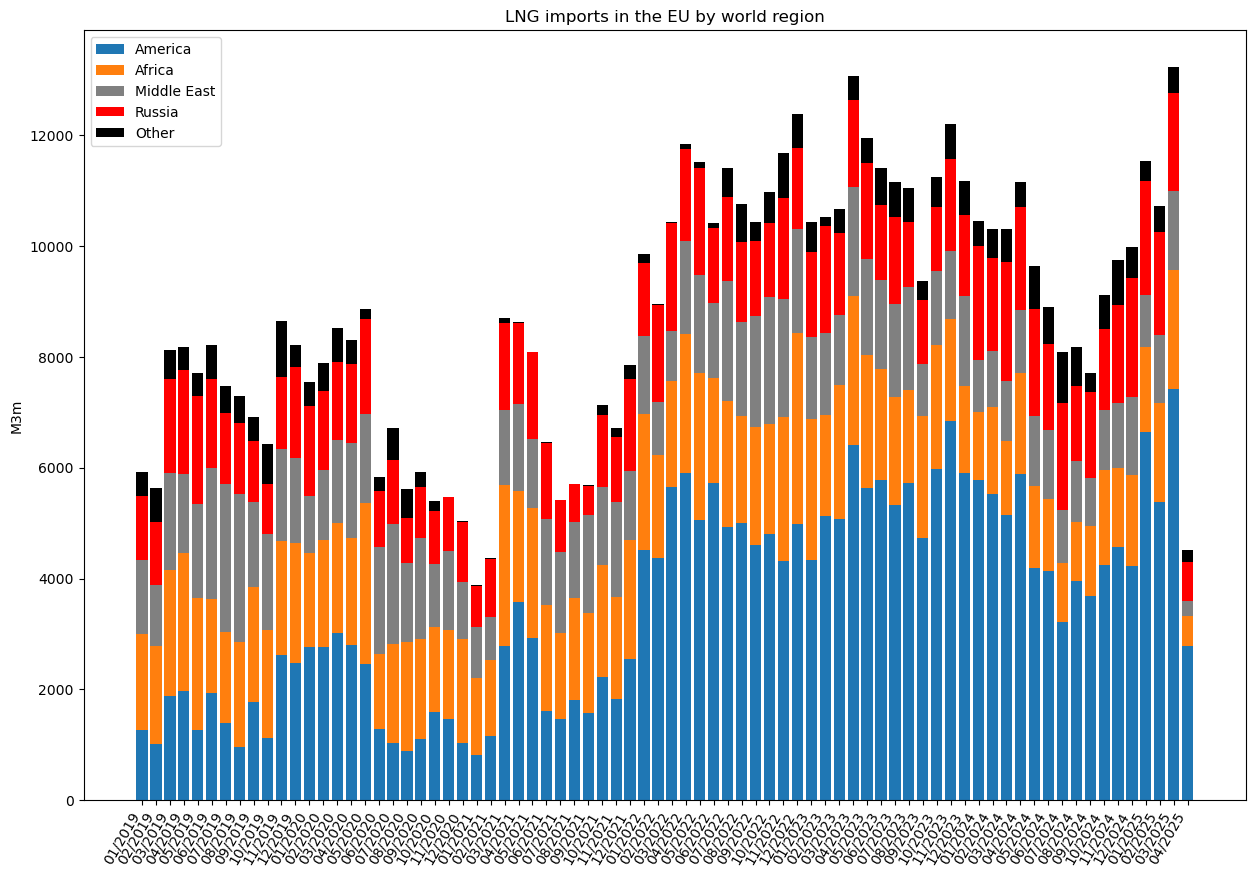

In [55]:
x = df_plot['dates']
width = 0.80       # the width of the bars: can also be len(x) sequence

fig, ax = plt.subplots(figsize=(15,10))

ax.bar(x, df_plot['America'], width, label='America')
ax.bar(x, df_plot['Africa'], width, bottom=df_plot['America'],
       label='Africa')
ax.bar(x, df_plot['Middle East'], width, bottom=df_plot['America']+df_plot['Africa'],
       label='Middle East',color='gray')
ax.bar(x, df_plot['Russia'], width, bottom=df_plot['America']+df_plot['Africa']+df_plot['Middle East'],
       label='Russia',color='red')
ax.bar(x, df_plot['Other'], width, bottom=df_plot['America']+df_plot['Africa']+df_plot['Middle East']+df_plot['Russia'],
       label='Other',color='black')

fig.set_facecolor('white')

plt.setp(ax.get_xticklabels(), rotation=60, horizontalalignment='right')

ax.set_ylabel('M3m')
ax.set_title('LNG imports in the EU by world region')
ax.legend()

plt.show()

### In bcm

In [56]:
df_late.columns

Index(['Qatar', 'Algeria', 'Nigeria', 'Russia', 'Norway', 'United States',
       'Trinidad & Tobago', 'Egypt', 'Other'],
      dtype='object', name='Origin_Berthcountry')

In [57]:
df_bcm = df_late/1000

In [58]:
df_bcm = df_bcm['2021-09':]

<Axes: title={'center': 'LNG imports in the EU by supplier'}, ylabel='bcm'>

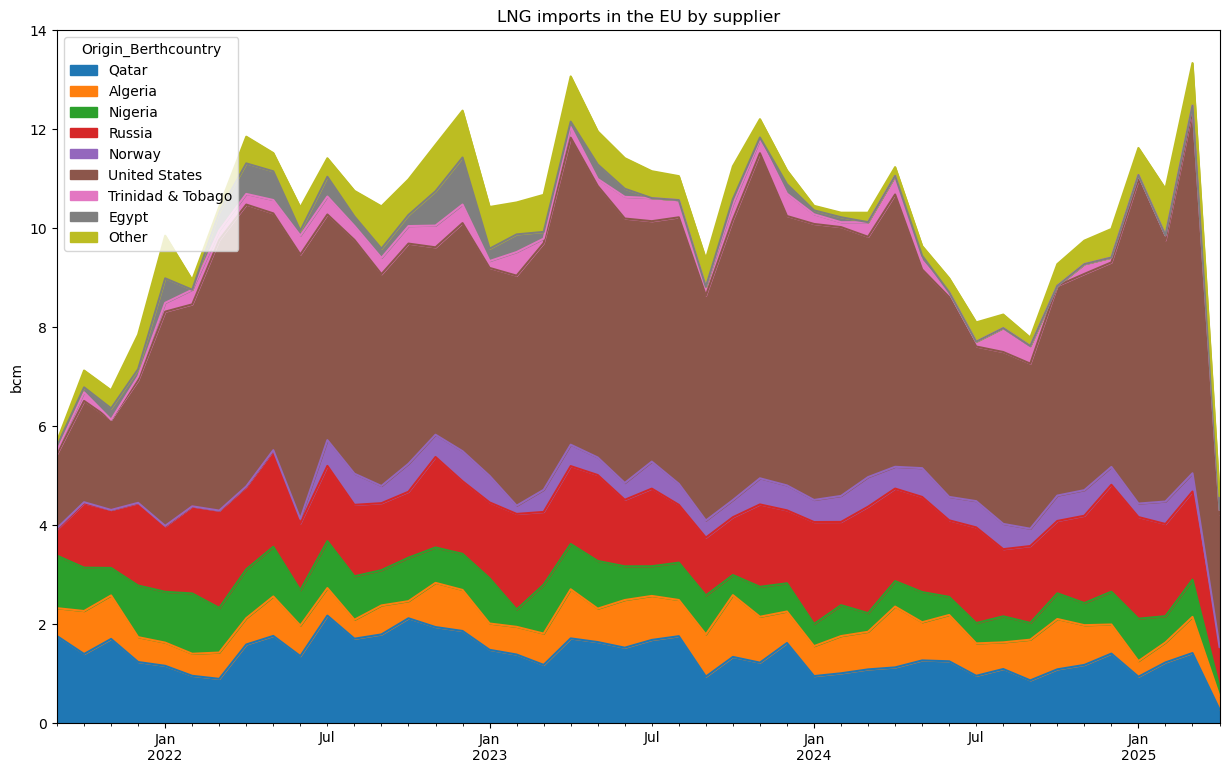

In [59]:
df_bcm.plot(figsize=(15, 9),kind='area',ylabel='bcm', title='LNG imports in the EU by supplier')

In [60]:
df_twh = df_bcm*10.3 

In [61]:
df_twh = df_twh[['United States','Russia', 'Qatar',  'Norway', 'Algeria', 'Nigeria', 'Trinidad & Tobago', 'Egypt', 'Other']]

In [62]:
colors = {'United States':'#0080C7','Russia':'#E67425', 'Qatar':'#FFC000',  'Norway':'black', 'Algeria':'orange', 'Nigeria':'#2BB0CB', 'Trinidad & Tobago':'#0080C7', 'Egypt':'blue', 'Other':'#58A944'}

<Axes: title={'center': 'LNG imports in the EU by supplier'}, ylabel='bcm'>

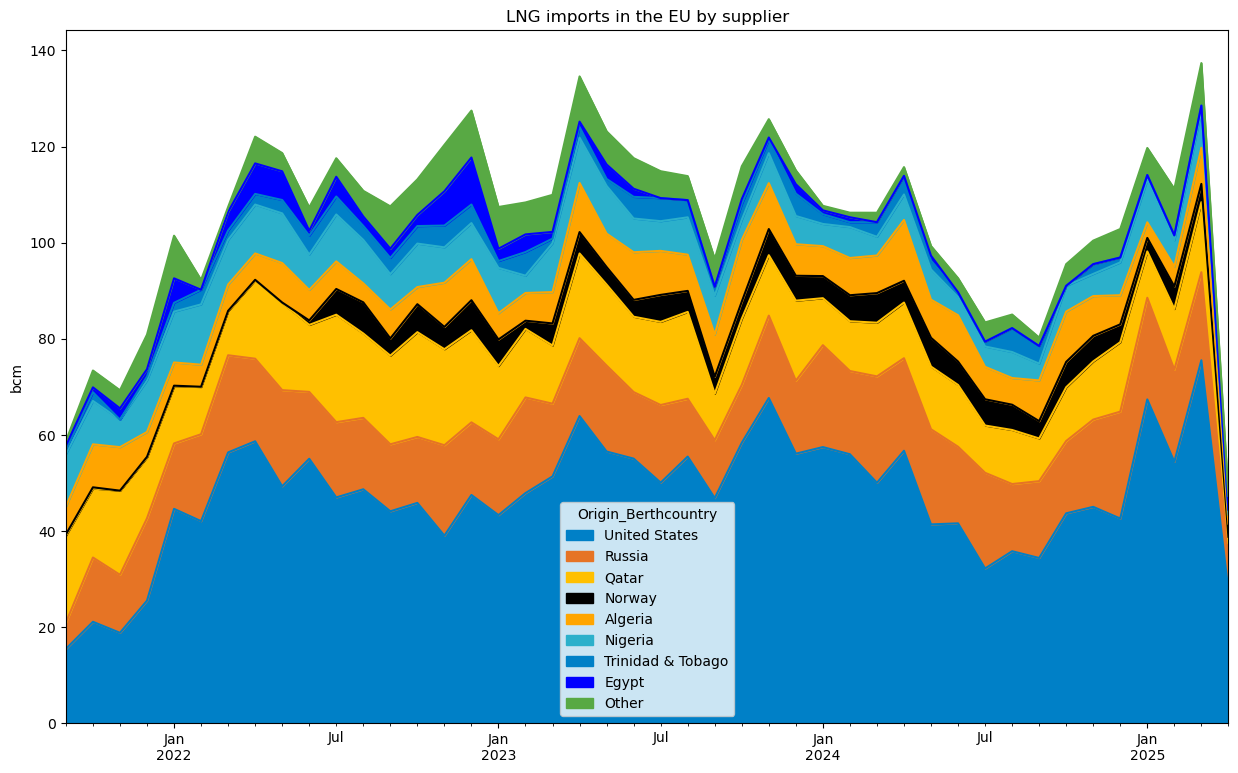

In [63]:
df_twh.plot(figsize=(15, 9),kind='area',ylabel='bcm', title='LNG imports in the EU by supplier',color=colors)

### Checks against the Quarterly report of the Commission

In [64]:
df_bcm['M_Y'] = df_bcm.index.strftime('%m_%Y')

<Axes: title={'center': 'LNG imports in the EU by supplier'}, xlabel='month', ylabel='bcm'>

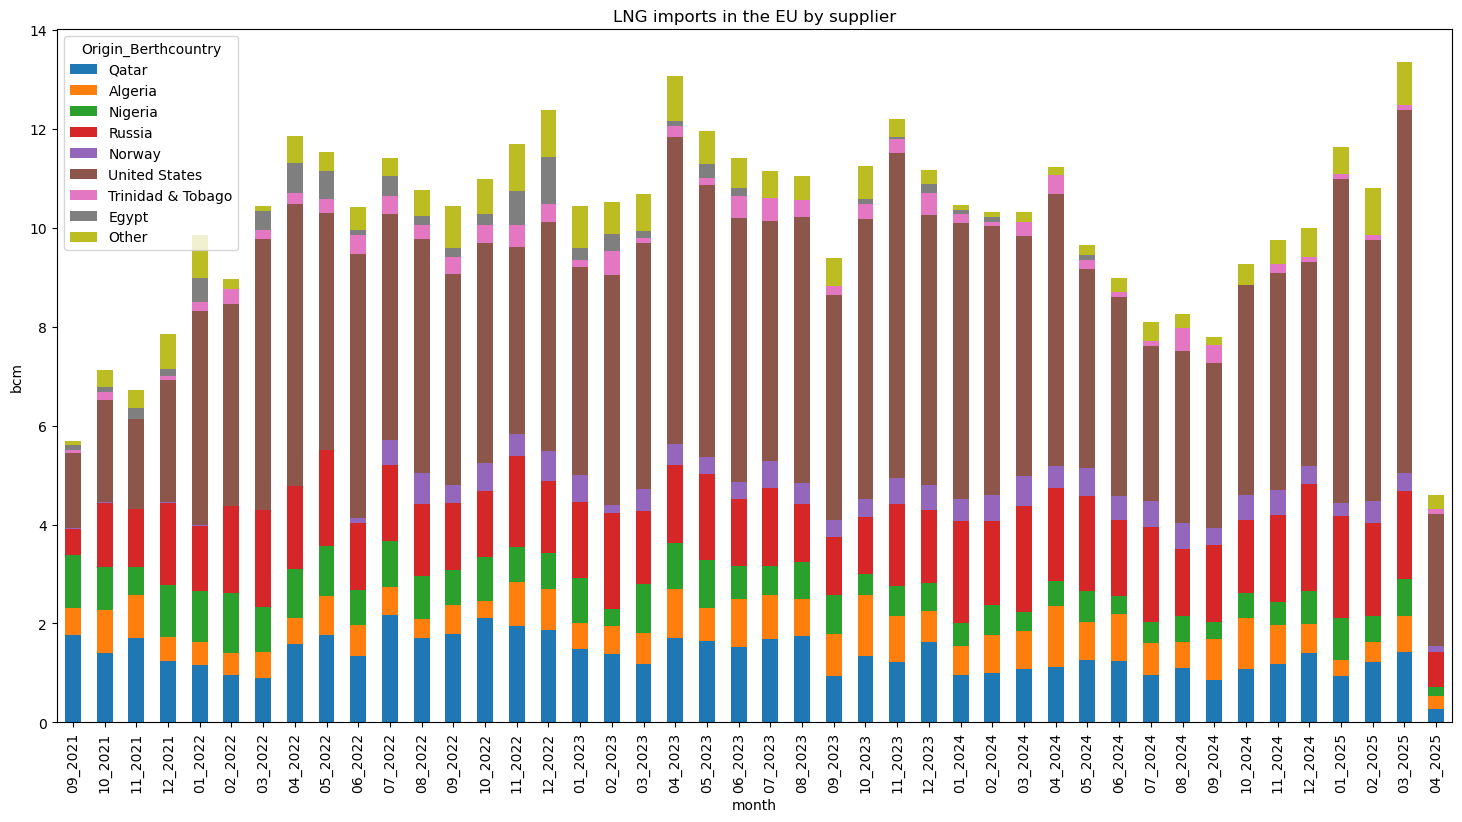

In [65]:
df_bcm.plot(x='M_Y', kind='bar', stacked=True,
        title='LNG imports in the EU by supplier',figsize=(18, 9),
           ylabel='bcm', xlabel='month')

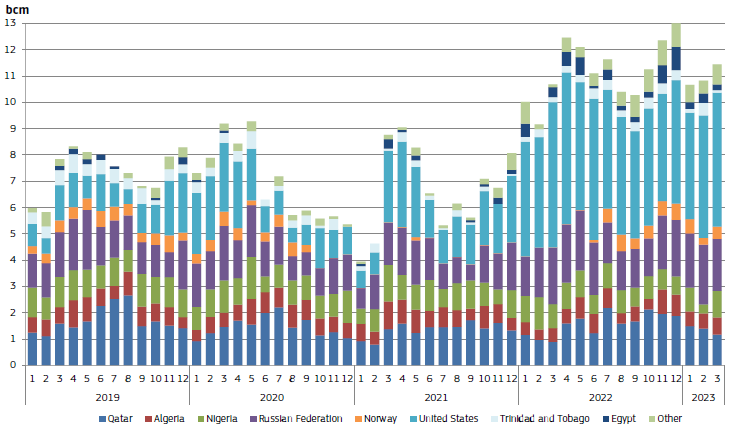

In [66]:
from IPython.display import Image
Image("Commission Qreport 2023 by source.png")

In the second quarter of 2022, the United States proved to be the biggest LNG supplier of the EU, by a large margin to its competitors, ensuring 16 bcm of the EU LNG imports within a single quarter (for comparison: EU LNG imports from the US amounted to 22 bcm in 2021 as whole), representing around 45% of the total imports. Year-on-year, LNG imports from the US were up by 117%, and the share of the US in total EU LNG imports rose by 14 percentage points. In 2022 so far, the EU imported around 39 bcm LNG from the US, implying that the objective of the March 2022 EU-US joint statement on energy security12, which foresaw and increase of 15 bcm compared to 2021, has already been fulfilled.

In [67]:
df_bcm['United States'].loc['2022-04':'2022-06'].sum()

15.82021098

In [68]:
df_bcm['United States'].loc['2021'].sum()

7.844681276999999

In [69]:
df_bcm['United States'].loc['2022-01':'2022-08'].sum()

38.982955806

In spite of ongoing geopolitical tensions, Russia remained the second biggest LNG supplier of the EU, representing 18% (6.5 bcm, up by 28% year-on-year). Qatar was the third most important EU LNG source (with an import share of 13% and imports amounting to 4.6 bcm, +7%), followed by Nigeria on the fourth place (with an import share of only 8% - 2.7 bcm, but falling by 11% year-on-year). LNG imports from Algeria amounted to 2.1 bcm, falling by 12% year-on-year and representing only 6% of the total imports. Within other sources, LNG imports from Egypt rose almost five-fold year-on-year, reaching 1.3 bcm (4% of the total EU imports), while those from Trinidad and Tobago amounted to 0.9 bcm and ensured around 3% of the total EU LNG imports – See Figure 16

In [70]:
df_bcm['Russia'].loc['2022-04':'2022-06'].sum()

4.962656916

In [71]:
df_bcm['Qatar'].loc['2022-04':'2022-06'].sum()

4.70215611

In [72]:
df_bcm['Nigeria'].loc['2022-04':'2022-06'].sum()

2.704700295

In [73]:
df_bcm['Algeria'].loc['2022-04':'2022-06'].sum()

1.947744144

In [74]:
dff_M3m['Egypt'].loc['2022-04':'2022-06'].sum() # in M3m

1295.7314039999999

In [75]:
df_bcm['Trinidad & Tobago'].loc['2022-04':'2022-06'].sum()

0.866926557

In Q2 2022, Norway still had a very low share (around 0.3%) in total EU LNG imports, however, in June the Hammerfest LNG liquefaction terminal restarted its operation, being under repair and maintenance works since the fire incident at the end of September 2020 (See more in Chapter 1.4) and is expected to measurably contribute to the EU LNG supply as of from the second half of 2022.

In [76]:
N=df_bcm['Norway'].loc['2022-04':'2022-06'].sum()
T=df_bcm[['Qatar','Algeria','Nigeria','Russia','Norway','United States','Trinidad & Tobago','Egypt','Other']].loc['2022-04':'2022-06'].sum()

In [77]:
TT= T.sum()

In [78]:
N/TT*100

0.3171755705759158

### Single-out Spain and Portugal

In [79]:
df_tot = df_EU27.reset_index()

In [80]:
iberia = df_tot[df_tot['Port_Country'].isin(['Spain','Portugal'])]

In [81]:
cols = iberia.iloc[:,:2]

In [82]:
# convert to M3m
values = iberia.iloc[:,2:]*converter

TypeError: can't multiply sequence by non-int of type 'float'

In [107]:
iberia = pd.concat([cols,values], axis=1)

NameError: name 'values' is not defined

In [108]:
iberia.to_excel(r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2023-04 How the EU can phase out Russian LNG\Data\Iberian LNG by source.xlsx')

OSError: Cannot save file into a non-existent directory: 'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2023-04 How the EU can phase out Russian LNG\Data'